<a href="https://colab.research.google.com/github/sethamonyarkoh/DataMining-Portfolio/blob/main/COMP590_Module_7_Bayesian_Visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Bayesian Visualization with Synthetic Data

Setup

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

np.random.seed(42)


Generate Synthetic Data

We simulate test scores from a population with unknown mean.

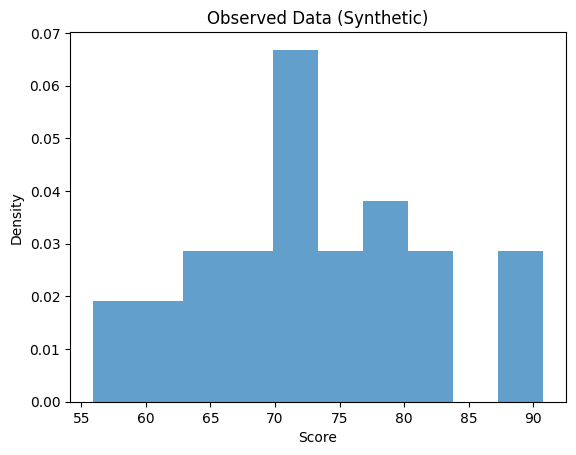

In [ ]:
# True (unknown) population parameters
true_mean = 75
true_sd = 10

# Observed data (sample)
n = 30
data = np.random.normal(true_mean, true_sd, size=n)

# Plot observed data
plt.hist(data, bins=10, density=True, alpha=0.7)
plt.xlabel("Score")
plt.ylabel("Density")
plt.title("Observed Data (Synthetic)")
plt.show()


Specify a Prior for the Mean

We assume:

•	Known standard deviation

•	Unknown mean

•	Normal prior on the mean


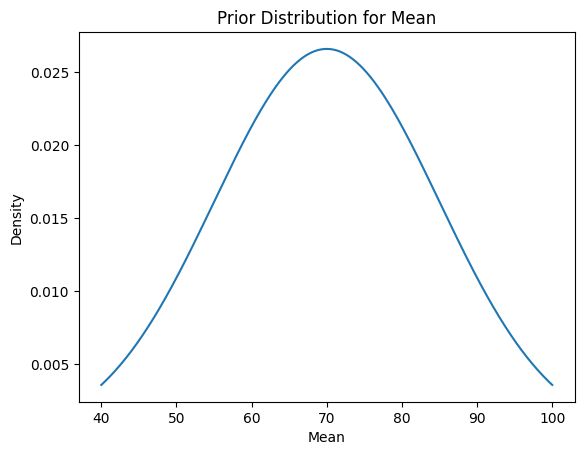

In [ ]:
# Prior for the mean
prior_mean = 70
prior_sd = 15

mu_vals = np.linspace(40, 100, 500)
prior_pdf = stats.norm.pdf(mu_vals, prior_mean, prior_sd)

plt.plot(mu_vals, prior_pdf)
plt.title("Prior Distribution for Mean")
plt.xlabel("Mean")
plt.ylabel("Density")
plt.show()


Compute the Posterior Analytically

For a Normal likelihood with known variance and Normal prior, the posterior is Normal.



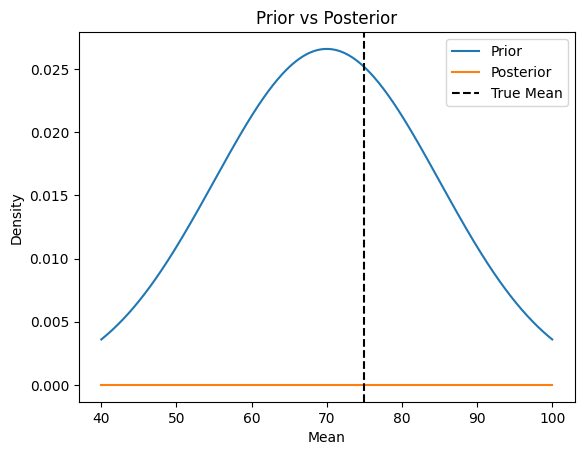

In [ ]:
# Known variance
sigma = true_sd

import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats


# Posterior parameters
posterior_sd = 1 / np.sqrt(1/prior_sd**2 + n/sigma**2)
posterior_mean = (1 / posterior_sd**2) * (
    prior_mean/prior_sd**2 + np.sum(data)/sigma**2
)

posterior_pdf = stats.norm.pdf(mu_vals, posterior_mean, posterior_sd)

# Prior vs Posterior (Core Visualization)
plt.plot(mu_vals, prior_pdf, label="Prior")
plt.plot(mu_vals, posterior_pdf, label="Posterior")
plt.axvline(true_mean, color="black", linestyle="--", label="True Mean")
plt.legend()
plt.xlabel("Mean")
plt.ylabel("Density")
plt.title("Prior vs Posterior")
plt.show()

Posterior Samples

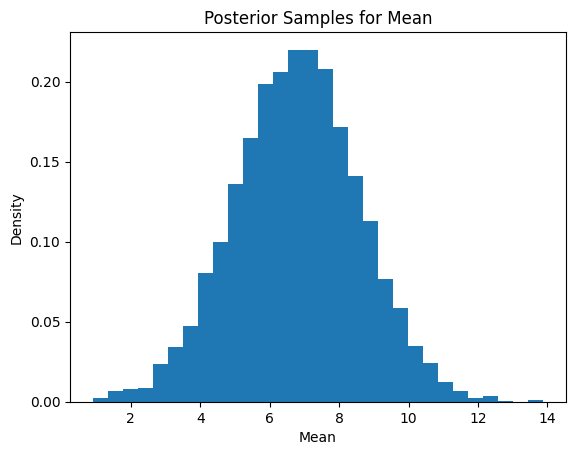

In [ ]:
posterior_samples = np.random.normal(
    posterior_mean, posterior_sd, size=5000
)

plt.hist(posterior_samples, bins=30, density=True)
plt.xlabel("Mean")
plt.ylabel("Density")
plt.title("Posterior Samples for Mean")
plt.show()


Posterior Predictive Simulation

Now we generate replicated data from the model.


In [ ]:
# Posterior predictive data
ppc_samples = []

for mu in posterior_samples[:500]:
    ppc_samples.append(
        np.random.normal(mu, sigma, size=n)
    )

ppc_means = [np.mean(x) for x in ppc_samples]


Posterior Predictive Check (PPC)

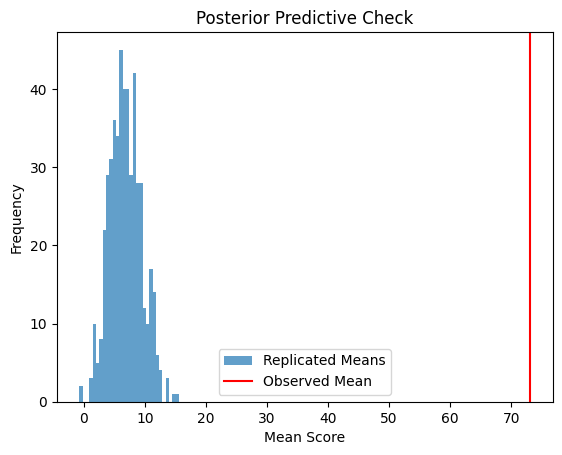

In [ ]:
plt.hist(ppc_means, bins=30, alpha=0.7, label="Replicated Means")
plt.axvline(np.mean(data), color="red", label="Observed Mean")
plt.xlabel("Mean Score")
plt.ylabel("Frequency")
plt.title("Posterior Predictive Check")
plt.legend()
plt.show()


Model Criticism Exercise

Ask students to break the model:


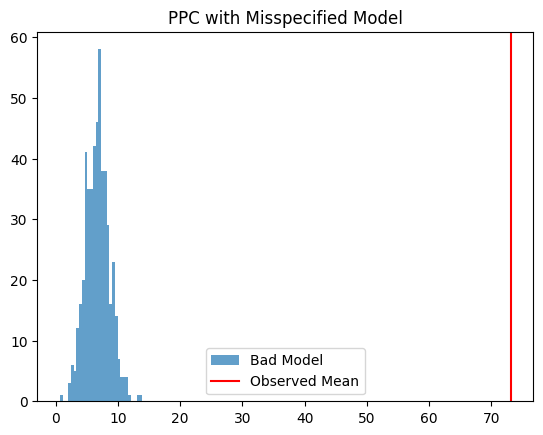

In [ ]:
# Misspecified model: wrong standard deviation
wrong_sigma = 3

bad_ppc = []
for mu in posterior_samples[:500]:
    bad_ppc.append(
        np.random.normal(mu, wrong_sigma, size=n)
    )

bad_means = [np.mean(x) for x in bad_ppc]

plt.hist(bad_means, bins=30, alpha=0.7, label="Bad Model")
plt.axvline(np.mean(data), color="red", label="Observed Mean")
plt.legend()
plt.title("PPC with Misspecified Model")
plt.show()



### Reflection Questions

1. How did visualization change your understanding of uncertainty?
2. Which plot was most informative?
3. Where did the model succeed?
4. Where did the model fail?
5. What assumption mattered most?
